In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('Iris.csv')

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df = df.iloc[:,1:]

In [5]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
encoder = LabelEncoder()

In [8]:
df['Species'] = encoder.fit_transform(df['Species'])

In [9]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [11]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

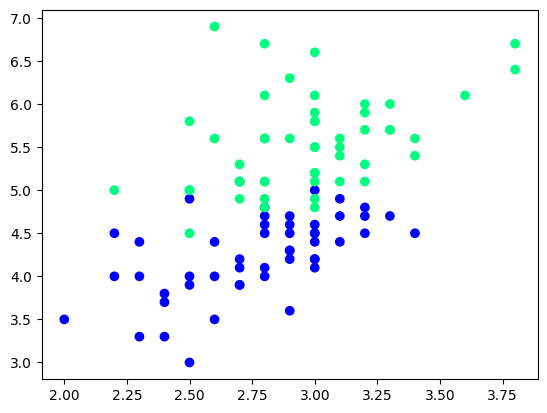

In [13]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [14]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
57,2.4,3.3,1
101,2.7,5.1,2
81,2.4,3.7,1
79,2.6,3.5,1
53,2.3,4.0,1
87,2.3,4.4,1
86,3.1,4.7,1
105,3.0,6.6,2
77,3.0,5.0,1
85,3.4,4.5,1


In [15]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [16]:
df_train

,SepalWidthCm,PetalLengthCm,Species
145,3.0,5.2,2
120,3.2,5.7,2
73,2.8,4.7,1
60,2.0,3.5,1
84,3.0,4.5,1
139,3.1,5.4,2
124,3.3,5.7,2
142,2.7,5.1,2
82,2.7,3.9,1
132,2.8,5.6,2


In [17]:
df_val

,SepalWidthCm,PetalLengthCm,Species
56,3.3,4.7,1
126,2.8,4.8,2
61,3.0,4.2,1
105,3.0,6.6,2
134,2.6,5.6,2


In [18]:
df_test

,SepalWidthCm,PetalLengthCm,Species
76,2.8,4.8,1
133,2.8,5.1,2
53,2.3,4.0,1
149,3.0,5.1,2
114,2.8,5.1,2


In [19]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [20]:
y_test

array([1, 2, 1, 2, 2])

## Case 1 - Bagging

In [21]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
145,3.0,5.2,2
82,2.7,3.9,1
120,3.2,5.7,2
124,3.3,5.7,2
145,3.0,5.2,2
120,3.2,5.7,2
124,3.3,5.7,2
139,3.1,5.4,2


In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [23]:
dt_bag1 = DecisionTreeClassifier()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


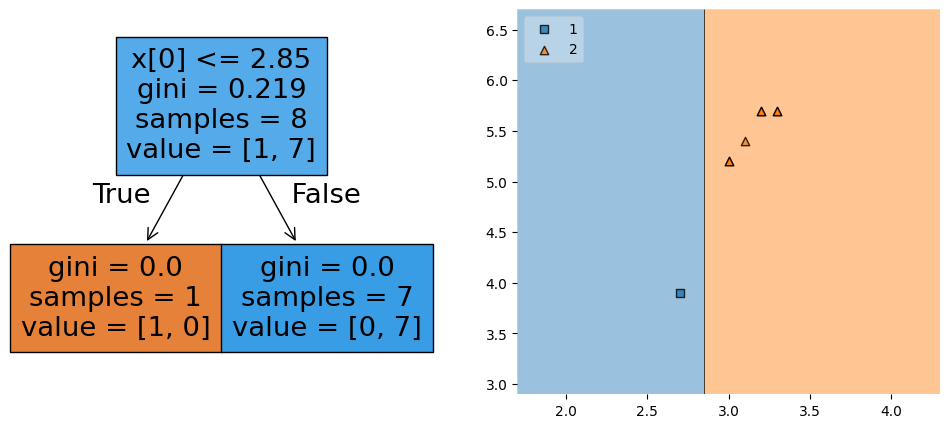

In [25]:
def evaluate(model, X, y):
    model.fit(X, y)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plot_tree(model, filled=True)

    plt.subplot(1,2,2)
    plot_decision_regions(X.values, y.values, clf=model, legend=2)

    plt.show()
evaluate(dt_bag1, X,y)

In [26]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
142,2.7,5.1,2
145,3.0,5.2,2
145,3.0,5.2,2
142,2.7,5.1,2
145,3.0,5.2,2
145,3.0,5.2,2
132,2.8,5.6,2
82,2.7,3.9,1


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


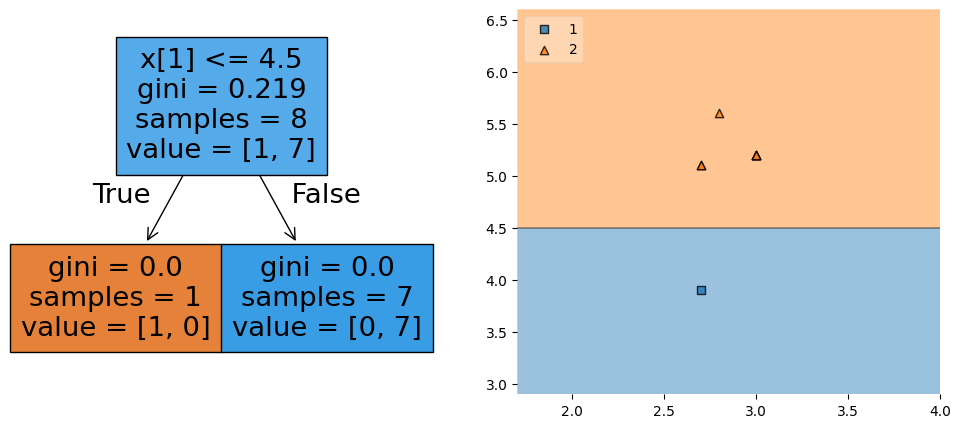

In [27]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2, X,y)

In [28]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
60,2.0,3.5,1
142,2.7,5.1,2
124,3.3,5.7,2
145,3.0,5.2,2
120,3.2,5.7,2
145,3.0,5.2,2
142,2.7,5.1,2
82,2.7,3.9,1


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


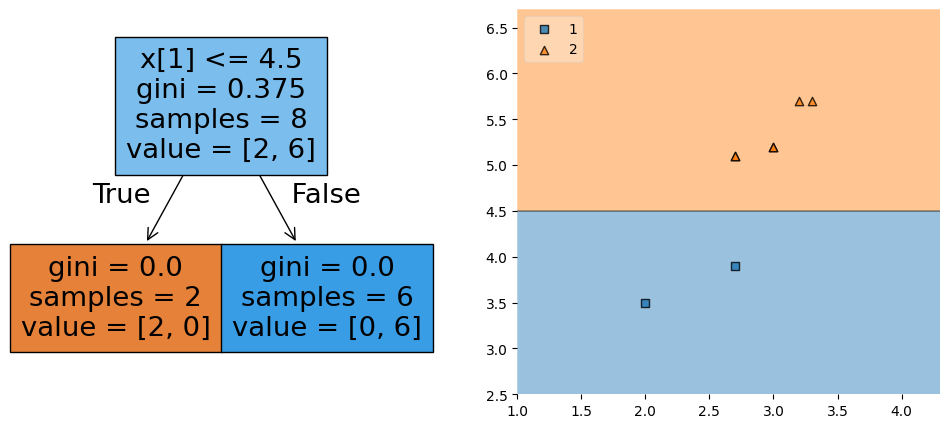

In [30]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [31]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

## Predict

In [32]:
df_test

,SepalWidthCm,PetalLengthCm,Species
76,2.8,4.8,1
133,2.8,5.1,2
53,2.3,4.0,1
149,3.0,5.1,2
114,2.8,5.1,2


In [33]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [2]
Predictor 3 [2]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Pasting

In [34]:
# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
145,3.0,5.2,2
120,3.2,5.7,2
73,2.8,4.7,1
60,2.0,3.5,1
84,3.0,4.5,1
139,3.1,5.4,2
124,3.3,5.7,2
142,2.7,5.1,2
82,2.7,3.9,1
132,2.8,5.6,2


In [35]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
73,2.8,4.7,1
82,2.7,3.9,1
139,3.1,5.4,2
84,3.0,4.5,1
132,2.8,5.6,2
120,3.2,5.7,2
60,2.0,3.5,1
142,2.7,5.1,2


## Random Subspaces

In [36]:
df1 = pd.read_csv('Iris.csv')
df1 = df1.sample(10)

In [37]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
14,15,5.8,4.0,1.2,0.2,Iris-setosa
138,139,6.0,3.0,4.8,1.8,Iris-virginica
101,102,5.8,2.7,5.1,1.9,Iris-virginica
103,104,6.3,2.9,5.6,1.8,Iris-virginica
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
121,122,5.6,2.8,4.9,2.0,Iris-virginica
33,34,5.5,4.2,1.4,0.2,Iris-setosa
116,117,6.5,3.0,5.5,1.8,Iris-virginica
63,64,6.1,2.9,4.7,1.4,Iris-versicolor


In [38]:
df1.sample(2,replace=True,axis=1)

,SepalLengthCm,PetalWidthCm
14,5.8,0.2
138,6.0,1.8
101,5.8,1.9
103,6.3,1.8
145,6.7,2.3
146,6.3,1.9
121,5.6,2.0
33,5.5,0.2
116,6.5,1.8
63,6.1,1.4


## Random Patches

In [39]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
14,15,5.8,4.0,1.2,0.2,Iris-setosa
138,139,6.0,3.0,4.8,1.8,Iris-virginica
101,102,5.8,2.7,5.1,1.9,Iris-virginica
103,104,6.3,2.9,5.6,1.8,Iris-virginica
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
121,122,5.6,2.8,4.9,2.0,Iris-virginica
33,34,5.5,4.2,1.4,0.2,Iris-setosa
116,117,6.5,3.0,5.5,1.8,Iris-virginica
63,64,6.1,2.9,4.7,1.4,Iris-versicolor


In [40]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,PetalLengthCm,SepalLengthCm
63,4.7,6.1
146,5.0,6.3
146,5.0,6.3
145,5.2,6.7
101,5.1,5.8
63,4.7,6.1
103,5.6,6.3
101,5.1,5.8
